In [1]:
pip install natsort

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2
#%load_ext profila
from electron_scattering import Environment, propagate_photons
import numba
numba.set_num_threads(8)
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
import timeit
from scipy import optimize
from numpy.polynomial import Hermite
import glob
from re import findall
from natsort import natsorted
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# import time
# from scipy.signal import fftconvolve, convolve


In [3]:
central_wavelength = 6563 * u.AA

eps = 1e-2
fbase = "scattering_counts_tau_"
fend = ".dat"

def gauss_convgaussexp(x,B,ef,A,w):
    width = 1e2*w
    efold = 1e3*ef
    y = B*np.convolve(np.exp(-0.5*(x/width)**2),np.exp(-np.abs(x/efold)),mode='full')
    start = int(len(x)*(len(x[x<0])/len(x)))
    stop = int(len(x)*len(x[x>=0])/len(x))
    add = len(x) - ((len(y)-stop)-start)
    return A*np.exp(-0.5*(x/width)**2) + y[start:-stop+add]


# Electron Scattering 10000K

## Read and fit simulations

In [4]:
dirname = "scattering_data_10K/"
path = dirname + fbase + '*' + fend
obetas = np.zeros((len(glob.glob(path)),5))
guess = None
for i,filename in enumerate(natsorted(glob.glob(path))):
    D = np.loadtxt(filename)
    tau = np.float64(findall(dirname + fbase + '([\d.]+)' + fend, filename)[0])
    x = D[0,:]*u.AA
    vel = c.c.to(u.km/u.s)*(x-central_wavelength)/central_wavelength
    counts = D[1,:] + eps
    sigma = np.sqrt(counts)

    y = (counts/np.max(counts))
    S = np.sqrt(counts)/np.max(counts)


    if guess is None:
        guess = np.array([0.3,1.0,.1,1.0])
    
    try:
        beta = optimize.curve_fit(gauss_convgaussexp, xdata=vel, ydata=y, sigma=S, p0=guess, bounds=[0,np.inf])[0]
        obetas[i,:] = np.append(tau,beta)
    except RuntimeError as e:
        print(e)
        
betas = np.delete(obetas,np.sum(obetas,axis=1)==0,axis=0)

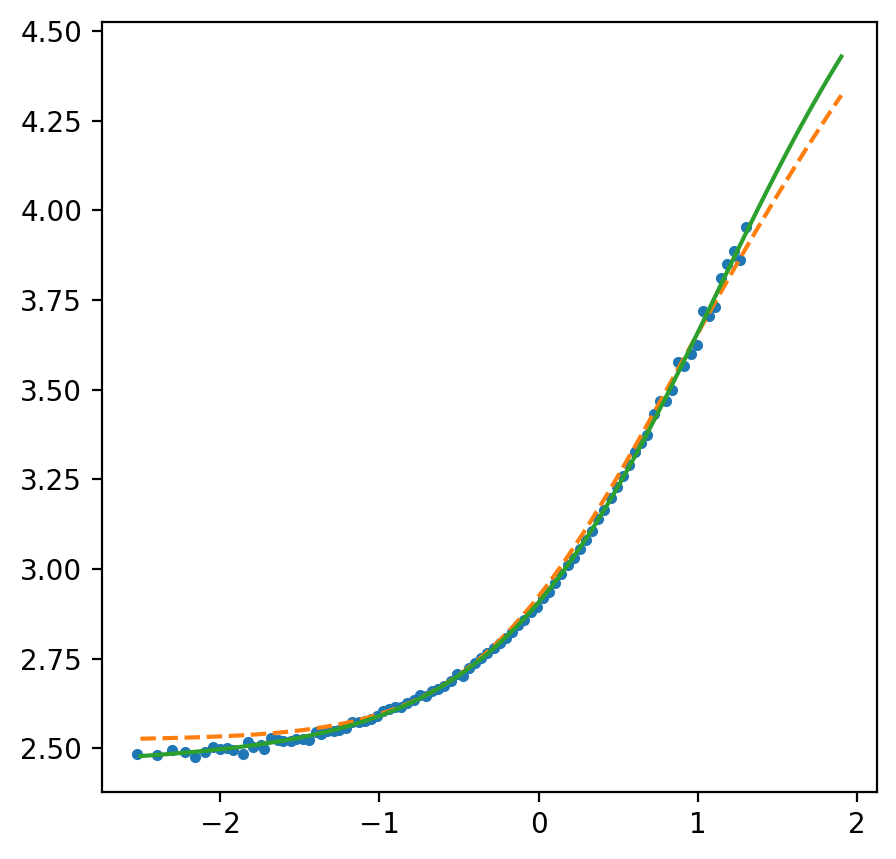

In [5]:
fig = plt.figure(figsize=(5,5),dpi=200)
def curved_lines(x,a0,b0,a1,b1,K,a):
    return (a0*x + b0) + 0.5*( 1 + np.tanh(K*(x-a)) )*( a1*x + b1 - (a0*x + b0) )

p0 = [0.008,2.55,0.5,3.5,0.80,0.27]
plt.plot(np.log10(betas[:,0]),3+np.log10(betas[:,2]),'.')
tau_vel = optimize.curve_fit(curved_lines, 
                             xdata=np.log10(betas[:,0]), 
                             ydata=3+np.log10(betas[:,2]), 
                             p0=p0)[0]

ts = np.linspace(-2.5,1.9,100)
plt.plot(ts,curved_lines(ts,*p0),'--',label='guess')
plt.plot(ts,curved_lines(ts,*tau_vel),label='fit')


## Plot tau-vel fit

Text(0.1, 0.63, '$\\tau_0$ = 0.96\n$a_0$ = 0.01\n$b_0$ = 2.50\n$a_1$ = 0.19\n$b_1$ = 4.55\n$k$ = 0.73\n')

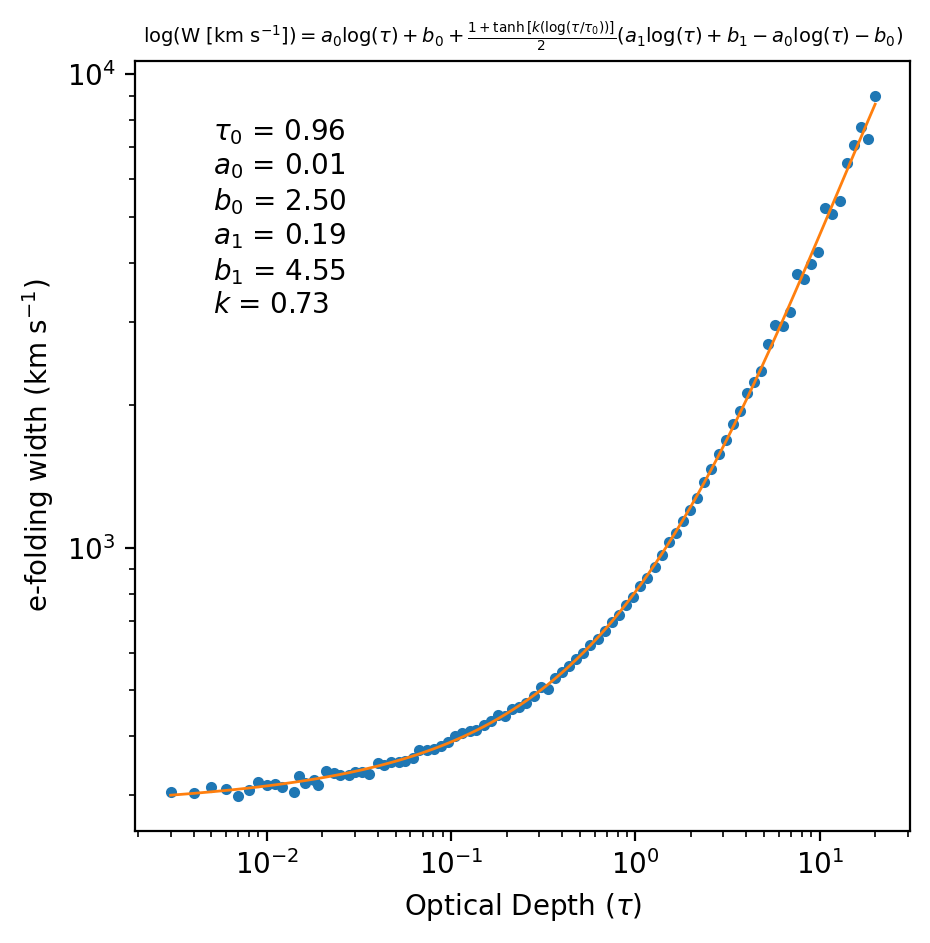

In [6]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")

plt.plot(betas[:,0],10**curved_lines(np.log10(betas[:,0]),*tau_vel),'-',lw=1.0)
eqntxt1 = r'$\log($W [km s$^{-1}$]$) = a_0\log(\tau) + b_0 + '
eqntxt2 = r'\frac{1 + \tanh{[k(\log(\tau/\tau_0))]}}{2} '
eqntxt3 = r'(a_1\log(\tau) + b_1 - a_0\log(\tau) - b_0)$'
eqntxt = eqntxt1 + eqntxt2 + eqntxt3
plt.title(eqntxt,fontsize=7)
px0 = r"$\tau_0$ = {x0:0.2f}".format(x0=tau_vel[5])
pa0 = r"$a_0$ = {a0:0.2f}".format(a0=tau_vel[0])
pb0 = r"$b_0$ = {b0:0.2f}".format(b0=tau_vel[1])
pa1 = r"$a_1$ = {a1:0.2f}".format(a1=tau_vel[2])
pb1 = r"$b_1$ = {b1:0.2f}".format(b1=tau_vel[3])
pk = r"$k$ = {k:0.2f}".format(k=tau_vel[4])
plt.annotate(text=px0 + "\n" +
                  pa0 + "\n" +
                  pb0 + "\n" +
                  pa1 + "\n" +
                  pb1 + "\n" +
                  pk + "\n",
             xy=(0.1,0.63),xycoords='axes fraction')

Text(0.1, 0.63, '$a$ = 420.55\n$b$ = 351.90\n')

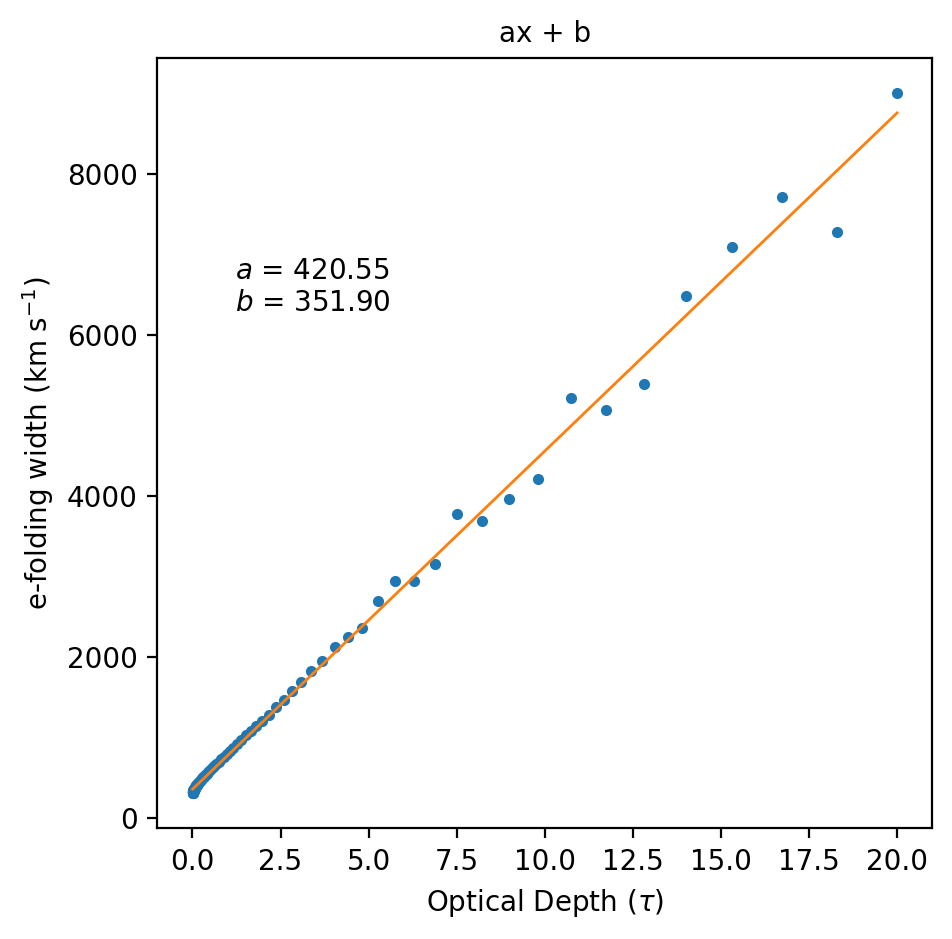

In [7]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")
def linfunc(x,a,b):
    return a*x + b

L = optimize.curve_fit(linfunc,xdata=betas[:,0],ydata=1000*betas[:,2])[0]
plt.plot(betas[:,0],linfunc(betas[:,0],*L),'-',lw=1.0)
plt.title("ax + b",fontsize=10)
pa0 = r"$a$ = {a0:0.2f}".format(a0=L[0])
pb0 = r"$b$ = {b0:0.2f}".format(b0=L[1])
plt.annotate(text=pa0 + "\n" + pb0 + "\n", xy=(0.1,0.63),xycoords='axes fraction')

# Electron Scattering 30000K

## Read and fit simulations

In [8]:
dirname = "scattering_data_T=30kK/"
path = dirname + fbase + '*' + fend
obetas = np.zeros((len(glob.glob(path)),5))
guess = None
for i,filename in enumerate(natsorted(glob.glob(path))):
    D = np.loadtxt(filename)
    tau = np.float64(findall(dirname + fbase + '([\d.]+)' + fend, filename)[0])
    x = D[0,:]*u.AA
    vel = c.c.to(u.km/u.s)*(x-central_wavelength)/central_wavelength
    counts = D[1,:] + eps
    sigma = np.sqrt(counts)

    y = (counts/np.max(counts))
    S = np.sqrt(counts)/np.max(counts)


    if guess is None:
        guess = np.array([0.3,1.0,0.1,1.0])
    
#     print(i,tau,betas[i-1,2])
    try:
        beta = optimize.curve_fit(gauss_convgaussexp, xdata=vel.value, ydata=y, sigma=S, p0=guess, bounds=[0,np.inf])[0]
        obetas[i,:] = np.append(tau,beta)
    except RuntimeError as e:
        print(e)
        
betas = np.delete(obetas,np.sum(obetas,axis=1)==0,axis=0)

Fitted parameters: [0.03456189 2.81207676 0.4        4.06126334 0.80672208 0.63172061]


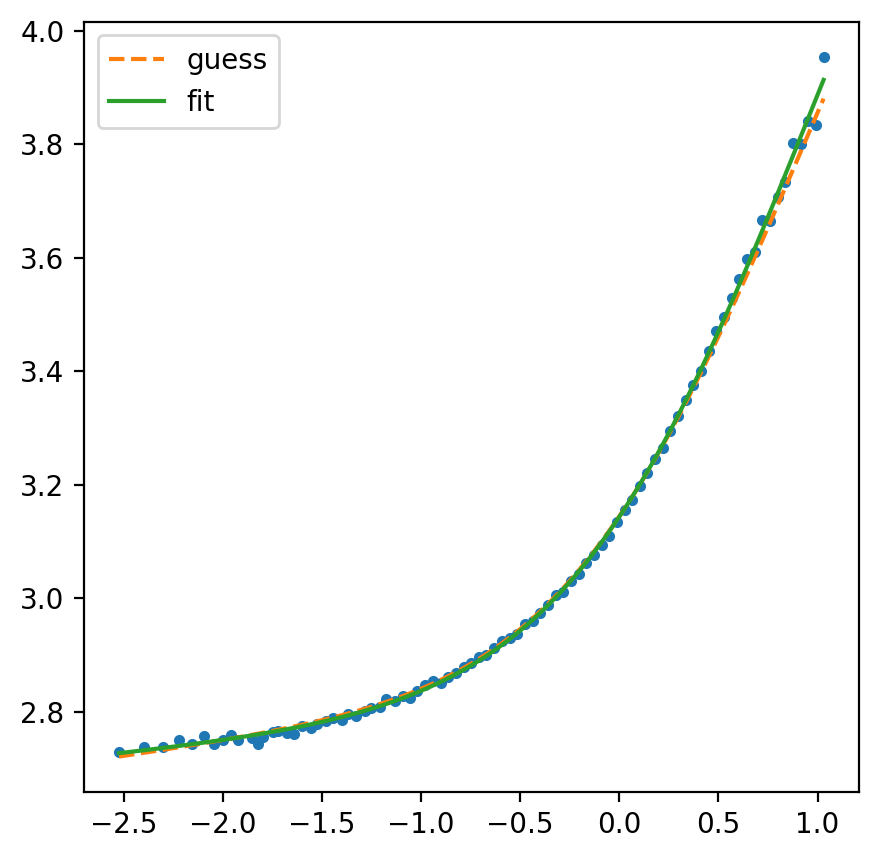

In [9]:
fig = plt.figure(figsize=(5,5),dpi=200)
def curved_lines(x,a0,b0,a1,b1,K,a):
    return (a0*x + b0) + 0.5*( 1 + np.tanh(K*(x-a)) )*( a1*x + b1 - (a0*x + b0) )

# p0 = [0.050,2.856,0.56,3.55,0.80,0.2]
p0 = [0.05271329,2.856, 0.50243673, 3.72608545, 0.81719568, 0.43001051]

# p0 = [ 0.01940876,  2.76751826, -2.12825722,  9.436214,    0.87468633,  1.61401961]


xdata = np.log10(betas[:,0])
ydata = np.log10(betas[:,2]) + 3
lower = np.array([0, 2.8, 0.4, 3.0, 0.4, -1.0])
upper = np.array([0.2, 3.0, 0.6, 4.5, 1.4, 1.0])
bounds = (lower,upper)

try:
    tau_vel, pcov = optimize.curve_fit(curved_lines, xdata, ydata, p0=p0, bounds=bounds)#, max_nfev=50000)
    print("Fitted parameters:", tau_vel)
except RuntimeError as e:
    print("Error during fitting:", e)

ts = np.linspace(-5.5,3.9,100)
plt.plot(xdata,ydata,'.')
plt.plot(xdata,curved_lines(xdata,*p0),'--',label='guess')
# plt.plot(ts,curved_lines(ts,*p0),'--',label='guess')
# plt.plot(ts,curved_lines(ts,*tau_vel),'-',label='fit')
plt.plot(xdata,curved_lines(xdata,*tau_vel),label='fit')
plt.legend()

In [10]:
# fig, ax = plt.subplots()
# ax.plot(xdata, ydata, '.', label='Data')
# line, = ax.plot([], [], 'r-', label='Fit')
# ax.legend()

# def curved_lines(x,a0,a1,b1,K,a):
#     return (a0*x + 2.856) + 0.5*( 1 + np.tanh(K*(x-a)) )*( a1*x + b1 - (a0*x + 2.856) )

# p0 = [0.050,0.56,3.55,0.80,0.2]

# # Function to update the plot
# def update(frame):
#     # Ensure there are enough data points for fitting
#     if frame < len(p0):
#         return line,
    
#     # Perform curve fitting with a subset of the data
#     subset_x = xdata[:frame+1]
#     subset_y = ydata[:frame+1]
#     try:
#         params, _ = optimize.curve_fit(curved_lines, subset_x, subset_y, p0=p0)
#         y_fit = curved_lines(xdata, *params)
#         line.set_data(xdata, y_fit)
#         print(params)
#     except RuntimeError:
#         pass
#     return line,

# # Create the animation
# ani = FuncAnimation(fig, update, frames=len(xdata), blit=True, repeat=False)
# # Display the animation in the notebook
# HTML(ani.to_jshtml())

## Plot tau-vel fit

Text(0.1, 0.63, '$\\tau_0$ = 0.63\n$a_0$ = 0.03\n$b_0$ = 2.81\n$a_1$ = 0.40\n$b_1$ = 4.06\n$k$ = 0.81\n')

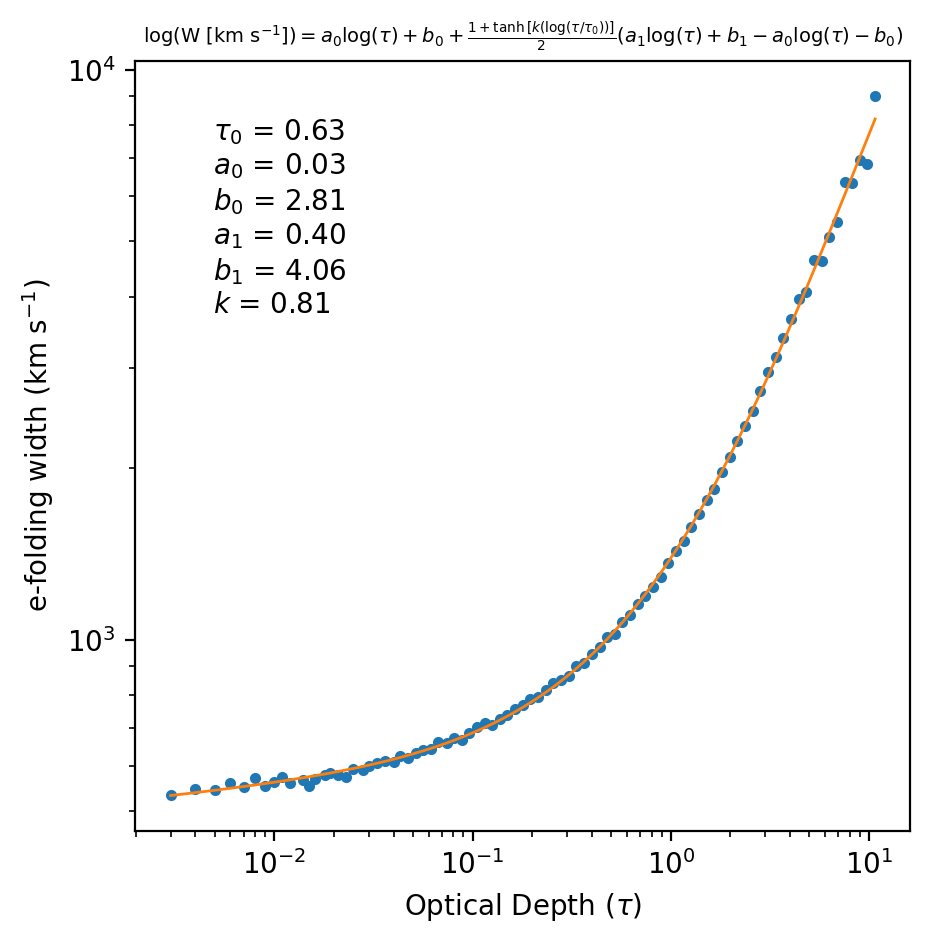

In [11]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")

plt.plot(betas[:,0],10**curved_lines(np.log10(betas[:,0]),*tau_vel),'-',lw=1.0)
eqntxt1 = r'$\log($W [km s$^{-1}$]$) = a_0\log(\tau) + b_0 + '
eqntxt2 = r'\frac{1 + \tanh{[k(\log(\tau/\tau_0))]}}{2} '
eqntxt3 = r'(a_1\log(\tau) + b_1 - a_0\log(\tau) - b_0)$'
eqntxt = eqntxt1 + eqntxt2 + eqntxt3
plt.title(eqntxt,fontsize=7)
px0 = r"$\tau_0$ = {x0:0.2f}".format(x0=tau_vel[5])
pa0 = r"$a_0$ = {a0:0.2f}".format(a0=tau_vel[0])
pb0 = r"$b_0$ = {b0:0.2f}".format(b0=tau_vel[1])
pa1 = r"$a_1$ = {a1:0.2f}".format(a1=tau_vel[2])
pb1 = r"$b_1$ = {b1:0.2f}".format(b1=tau_vel[3])
pk = r"$k$ = {k:0.2f}".format(k=tau_vel[4])
plt.annotate(text=px0 + "\n" +
                  pa0 + "\n" +
                  pb0 + "\n" +
                  pa1 + "\n" +
                  pb1 + "\n" +
                  pk + "\n",
             xy=(0.1,0.63),xycoords='axes fraction')

Text(0.1, 0.63, '$a$ = 720.95\n$b$ = 618.12\n')

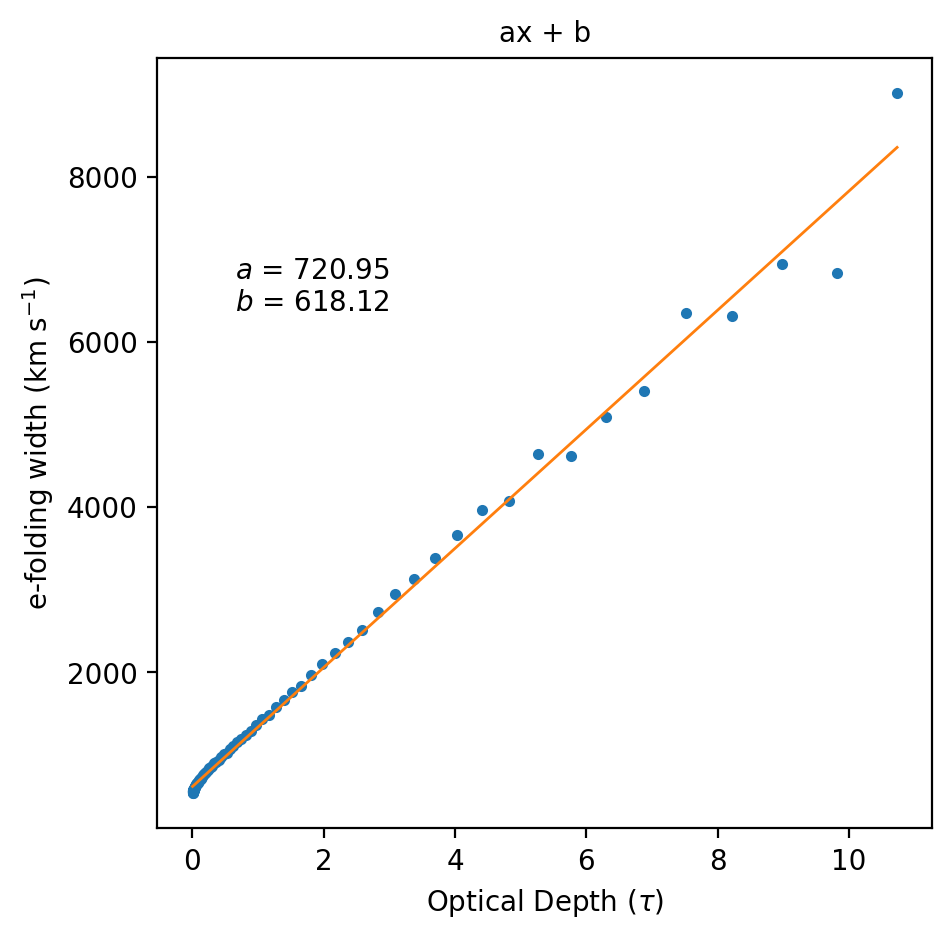

In [12]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")
def linfunc(x,a,b):
    return a*x + b

L = optimize.curve_fit(linfunc,xdata=betas[:,0],ydata=1000*betas[:,2])[0]
plt.plot(betas[:,0],linfunc(betas[:,0],*L),'-',lw=1.0)
plt.title("ax + b",fontsize=10)
pa0 = r"$a$ = {a0:0.2f}".format(a0=L[0])
pb0 = r"$b$ = {b0:0.2f}".format(b0=L[1])
plt.annotate(text=pa0 + "\n" + pb0 + "\n", xy=(0.1,0.63),xycoords='axes fraction')

# Electron Scattering 10000K Volumetric emission

## Read and fit simulations

In [13]:
dirname = "scattering_data_volumetric/"
path = dirname + fbase + '*' + fend
obetas = np.zeros((len(glob.glob(path)),5))
guess = None
for i,filename in enumerate(natsorted(glob.glob(path))):
    D = np.loadtxt(filename)
    tau = np.float64(findall(dirname + fbase + '([\d.]+)' + fend, filename)[0])
    x = D[0,:]*u.AA
    vel = c.c.to(u.km/u.s)*(x-central_wavelength)/central_wavelength
    counts = D[1,:] + eps
    sigma = np.sqrt(counts)

    y = (counts/np.max(counts))
    S = np.sqrt(counts)/np.max(counts)


    if guess is None:
        guess = np.array([0.3,1.0,0.1,1.0])
    
#     print(i,tau,betas[i-1,2])
    try:
        beta = optimize.curve_fit(gauss_convgaussexp, xdata=vel.value, ydata=y, sigma=S, p0=guess, bounds=[0,np.inf])[0]
        obetas[i,:] = np.append(tau,np.abs(beta))
#         obetas[i,:] = np.append(tau,(beta))
    except RuntimeError as e:
        print(e)
        
betas = np.delete(obetas,np.sum(obetas,axis=1)==0,axis=0)

Fitted parameters: [0.03688102 2.49414677 0.6        4.08600322 0.52065215 1.        ]


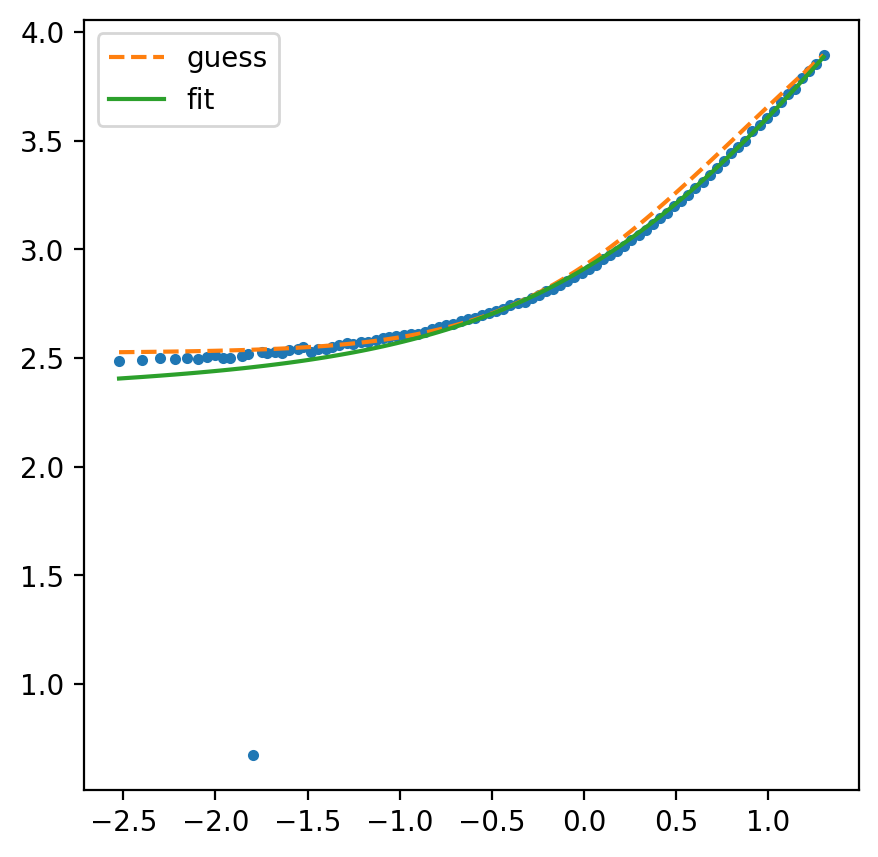

In [14]:
fig = plt.figure(figsize=(5,5),dpi=200)
def curved_lines(x,a0,b0,a1,b1,K,a):
    return (a0*x + b0) + 0.5*( 1 + np.tanh(K*(x-a)) )*( a1*x + b1 - (a0*x + b0) )

# p0 = [0.050,2.856,0.56,3.55,0.80,0.2]
# p0 = [0.05271329,2.856, 0.50243673, 3.72608545, 0.81719568, 0.43001051]

p0 = [0.008,2.55,0.5,3.5,0.80,0.27]


xdata = np.log10(betas[:,0])
ydata = np.log10(betas[:,2]) + 3
lower = np.array([0, 2.3, 0.4, 3.0, 0.4, -1.0])
upper = np.array([0.2, 3.0, 0.6, 4.5, 1.4, 1.0])
bounds = (lower,upper)

try:
    tau_vel, pcov = optimize.curve_fit(curved_lines, xdata, ydata, p0=p0, bounds=bounds)#, max_nfev=50000)
    print("Fitted parameters:", tau_vel)
except RuntimeError as e:
    print("Error during fitting:", e)

ts = np.linspace(-5.5,3.9,100)
plt.plot(xdata,ydata,'.')
plt.plot(xdata,curved_lines(xdata,*p0),'--',label='guess')
# plt.plot(ts,curved_lines(ts,*p0),'--',label='guess')
# plt.plot(ts,curved_lines(ts,*tau_vel),'-',label='fit')
plt.plot(xdata,curved_lines(xdata,*tau_vel),label='fit')
plt.legend()

In [15]:
# fig, ax = plt.subplots()
# ax.plot(xdata, ydata, '.', label='Data')
# line, = ax.plot([], [], 'r-', label='Fit')
# ax.legend()

# def curved_lines(x,a0,a1,b1,K,a):
#     return (a0*x + 2.856) + 0.5*( 1 + np.tanh(K*(x-a)) )*( a1*x + b1 - (a0*x + 2.856) )

# p0 = [0.050,0.56,3.55,0.80,0.2]

# # Function to update the plot
# def update(frame):
#     # Ensure there are enough data points for fitting
#     if frame < len(p0):
#         return line,
    
#     # Perform curve fitting with a subset of the data
#     subset_x = xdata[:frame+1]
#     subset_y = ydata[:frame+1]
#     try:
#         params, _ = optimize.curve_fit(curved_lines, subset_x, subset_y, p0=p0)
#         y_fit = curved_lines(xdata, *params)
#         line.set_data(xdata, y_fit)
#         print(params)
#     except RuntimeError:
#         pass
#     return line,

# # Create the animation
# ani = FuncAnimation(fig, update, frames=len(xdata), blit=True, repeat=False)
# # Display the animation in the notebook
# HTML(ani.to_jshtml())

## Plot tau-vel fit

Text(0.1, 0.63, '$\\tau_0$ = 1.00\n$a_0$ = 0.04\n$b_0$ = 2.49\n$a_1$ = 0.60\n$b_1$ = 4.09\n$k$ = 0.52\n')

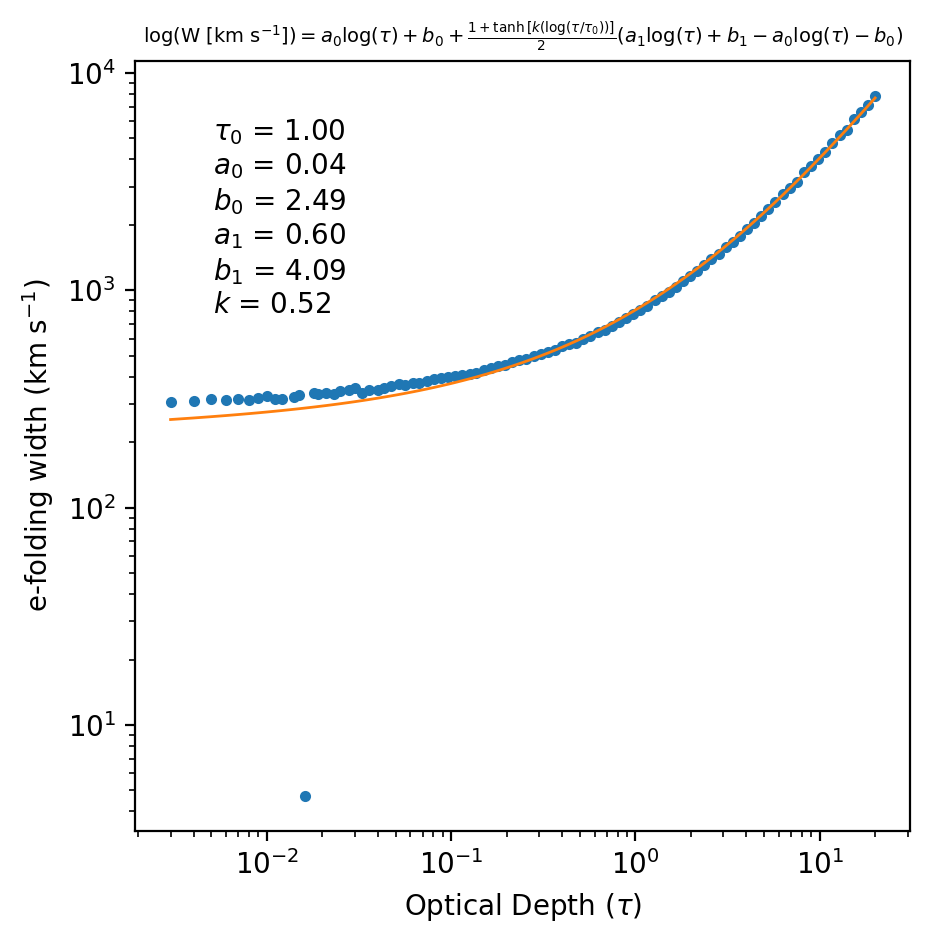

In [16]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")

plt.plot(betas[:,0],10**curved_lines(np.log10(betas[:,0]),*tau_vel),'-',lw=1.0)
eqntxt1 = r'$\log($W [km s$^{-1}$]$) = a_0\log(\tau) + b_0 + '
eqntxt2 = r'\frac{1 + \tanh{[k(\log(\tau/\tau_0))]}}{2} '
eqntxt3 = r'(a_1\log(\tau) + b_1 - a_0\log(\tau) - b_0)$'
eqntxt = eqntxt1 + eqntxt2 + eqntxt3
plt.title(eqntxt,fontsize=7)
px0 = r"$\tau_0$ = {x0:0.2f}".format(x0=tau_vel[5])
pa0 = r"$a_0$ = {a0:0.2f}".format(a0=tau_vel[0])
pb0 = r"$b_0$ = {b0:0.2f}".format(b0=tau_vel[1])
pa1 = r"$a_1$ = {a1:0.2f}".format(a1=tau_vel[2])
pb1 = r"$b_1$ = {b1:0.2f}".format(b1=tau_vel[3])
pk = r"$k$ = {k:0.2f}".format(k=tau_vel[4])
plt.annotate(text=px0 + "\n" +
                  pa0 + "\n" +
                  pb0 + "\n" +
                  pa1 + "\n" +
                  pb1 + "\n" +
                  pk + "\n",
             xy=(0.1,0.63),xycoords='axes fraction')

Text(0.1, 0.63, '$a$ = 374.35\n$b$ = 365.07\n')

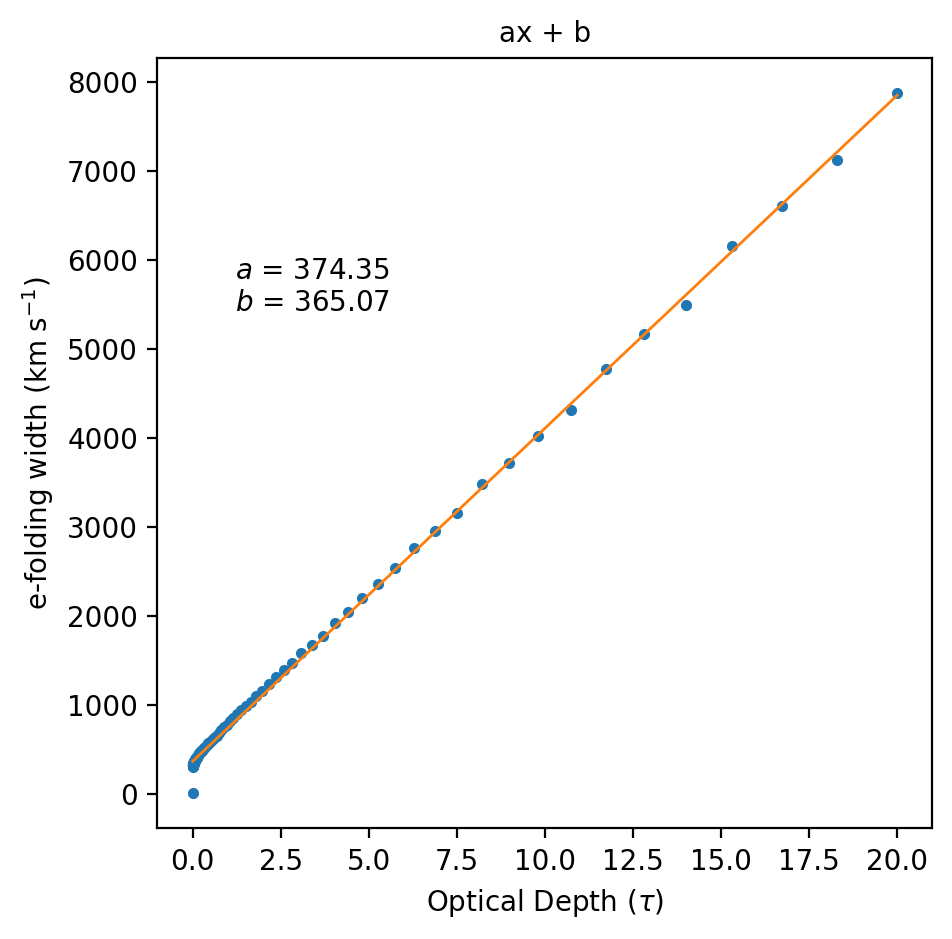

In [17]:
fig = plt.figure(figsize=(5,5),dpi=200)
plt.plot(betas[:,0],1000*betas[:,2],'.')
# plt.plot(betas[:,0],betas[:,4],'.')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r"Optical Depth ($\tau$)")
plt.ylabel(r"e-folding width (km s$^{-1}$)")
def linfunc(x,a,b):
    return a*x + b

L = optimize.curve_fit(linfunc,xdata=betas[:,0],ydata=1000*betas[:,2])[0]
plt.plot(betas[:,0],linfunc(betas[:,0],*L),'-',lw=1.0)
plt.title("ax + b",fontsize=10)
pa0 = r"$a$ = {a0:0.2f}".format(a0=L[0])
pb0 = r"$b$ = {b0:0.2f}".format(b0=L[1])
plt.annotate(text=pa0 + "\n" + pb0 + "\n", xy=(0.1,0.63),xycoords='axes fraction')

# Physical importance of parameters:

Is inner radius important?

Running default
Running R_inner=1e-3
Running volumetric


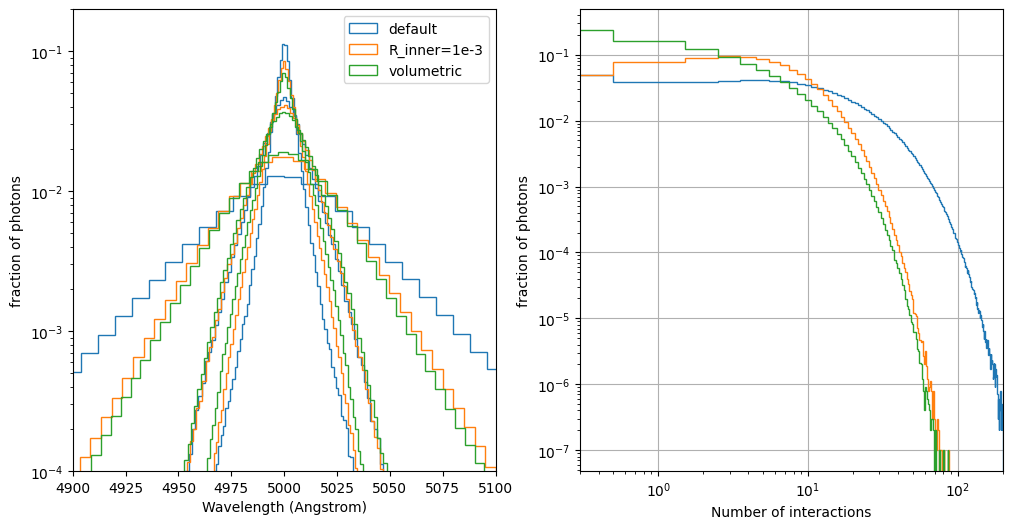

In [18]:
def plot_for_environment(env_obj, idx, label, axes):
    energies, interactions = propagate_photons(n_pkts=int(1e7), env_obj=env_obj)
    wavelengths = (energies * c.m_e * c.c**2).to(u.AA, equivalencies=u.spectral())
    axes[0].hist(wavelengths[interactions== 1].value, bins=100, histtype='step', color=f'C{idx}', density=True)
    axes[0].hist(wavelengths[interactions== 2].value, bins=100, histtype='step', color=f'C{idx}', density=True)
    axes[0].hist(wavelengths[interactions > 2].value, bins=100, histtype='step', color=f'C{idx}', label=label, density=True)
    
    axes[1].hist(interactions, bins=np.arange(-0.5, 200), histtype='step', color=f'C{idx}', density=True)


central_wavelength = 5000 * u.AA
freq_fact = (central_wavelength.to(u.J, equivalencies=u.spectral())/c.c**2/c.m_e).si

test_cases = [Environment(freq_fact=freq_fact, tau=3), 
              Environment(freq_fact=freq_fact, tau=3, R_inner=1e-5),
              Environment(freq_fact=freq_fact, tau=3, R_inner=1e-5, volume_init=True)]

names = ['default', 'R_inner=1e-3', 'volumetric']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, (env_obj, name) in enumerate(zip(test_cases, names)):
    print("Running", name)
    plot_for_environment(env_obj, idx, name, axes)

axes[0].set_xlabel('Wavelength (Angstrom)')
axes[0].set_ylabel('fraction of photons')
axes[0].set_xlim(central_wavelength.value - 100, central_wavelength.value + 100)
axes[0].set_yscale('log')
axes[0].set_ylim(1e-4,0.2)
axes[0].legend()

axes[1].set_xlabel('Number of interactions')
axes[1].set_ylabel('fraction of photons')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_xlim(0.3, 200)
axes[1].grid()